# Revolut FAQ RAG Chatbot — Build & Evaluate (Baseline)

A minimal single-turn RAG chatbot over Revolut help articles, evaluated
end-to-end on synthetic data with binary LLM-as-a-judge metrics.

**Stack:** `openai` for embeddings + chat, `numpy` for similarity search,
`json`/`pandas` for data. No frameworks, no vector DB — everything in memory.

**Pipeline:** generate synthetic queries → run them through RAG →
judge every answer → compute pass rates → iterate.

In [1]:
%pip install -q openai numpy pandas python-dotenv tqdm seaborn matplotlib


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


In [2]:
import json
import os
import numpy as np
import pandas as pd
from dotenv import load_dotenv
from openai import OpenAI

load_dotenv()

# Pandas display settings for better table rendering
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 60)
pd.set_option("display.max_rows", 10)
pd.set_option("display.width", None)

client = OpenAI(
    api_key=os.getenv("OPENAI_API_KEY"),
    base_url=os.getenv("BASE_URL"),
)

EMBED_MODEL = "text-embedding-3-small"
CHAT_MODEL = "gpt-3.5-turbo"  # weak model on purpose: makes failures easier to find and judges useful
TOP_K = 4

## 1. Load articles

In [3]:
ARTICLES_PATH = "data/revolut_help_articles.jsonl"

articles = []
with open(ARTICLES_PATH, "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        articles.append(json.loads(line))

print(f"Loaded {len(articles)} articles")
print("Example:", articles[0]["title"])

Loaded 786 articles
Example: How can I see my cashflow analytics?


## 2. Embed all articles

We embed `title + content_text` so the title contributes to retrieval. Batched to keep things fast.

In [4]:
def article_to_text(a):
    return f"{a['title']}\n\n{a['content_text']}"

def embed_texts(texts, batch_size=100):
    out = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i : i + batch_size]
        resp = client.embeddings.create(model=EMBED_MODEL, input=batch)
        out.extend([d.embedding for d in resp.data])
    return np.array(out, dtype=np.float32)

texts = [article_to_text(a) for a in articles]
embeddings = embed_texts(texts)

# L2-normalize once so cosine similarity is just a dot product
embeddings = embeddings / np.linalg.norm(embeddings, axis=1, keepdims=True)

print("Embeddings shape:", embeddings.shape)

Embeddings shape: (786, 1536)


## 3. Retrieval

In [5]:
def retrieve(query, k=TOP_K):
    q_emb = client.embeddings.create(model=EMBED_MODEL, input=[query]).data[0].embedding
    q_vec = np.array(q_emb, dtype=np.float32)
    q_vec = q_vec / np.linalg.norm(q_vec)

    scores = embeddings @ q_vec
    top_idx = np.argsort(-scores)[:k]
    return [(int(i), float(scores[i]), articles[i]) for i in top_idx]

## 4. Single-turn chat

In [6]:
SYSTEM_PROMPT = (
    "You are a Revolut customer support assistant. "
    "Answer the user's question using ONLY the provided help articles. "
    "If the answer is not in the articles, say you don't know. "
    "Be concise and reference steps from the articles when relevant."
)

def format_context(hits):
    parts = []
    for rank, (idx, score, art) in enumerate(hits, start=1):
        parts.append(
            f"[Article {rank}] {art['title']}\n{art['content_text']}"
        )
    return "\n\n---\n\n".join(parts)

def ask(question, k=TOP_K):
    hits = retrieve(question, k=k)
    context = format_context(hits)

    user_msg = (
        f"Help articles:\n\n{context}\n\n"
        f"Question: {question}"
    )

    resp = client.chat.completions.create(
        model=CHAT_MODEL,
        messages=[
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": user_msg},
        ],
        temperature=0.2,
    )
    answer = resp.choices[0].message.content
    return answer, hits

## 5. Try it

In [7]:
question = "как открыть аккаунт в монзо"

answer, hits = ask(question)

print("Q:", question)
print("\nA:", answer)
print("\nRetrieved articles:")
for rank, (idx, score, art) in enumerate(hits, start=1):
    print(f"  {rank}. [{score:.3f}] {art['title']}")

Q: как открыть аккаунт в монзо

A: I'm sorry, I don't have information on how to open an account with Monzo.

Retrieved articles:
  1. [0.369] Open a Revolut – Kids & Teens account
  2. [0.357] Duplicate account
  3. [0.337] Open an investment account
  4. [0.331] Change or verify email address


## 6. Generate synthetic dataset

With zero real user data, we generate queries as the Cartesian product of persona × scenario × modifier. Personas define who is asking (country, tone, phrasing), scenarios define the support problem, and modifiers define the mood/circumstance. This product gives systematic coverage instead of ad-hoc examples.

In [8]:
from generate_dataset import PERSONAS, SCENARIOS, MODIFIERS, generate_queries
import asyncio

# Show our seeds
print(f"Personas: {len(PERSONAS)}")
print(f"Scenarios: {len(SCENARIOS)}")
print(f"Modifiers: {len(MODIFIERS)}")
print(f"Total combinations: {len(PERSONAS) * len(SCENARIOS) * len(MODIFIERS)}")

# Generate or load queries
QUERIES_PATH = "data/synthetic_queries.csv"

if not os.path.exists(QUERIES_PATH):
    print("Generating synthetic queries...")
    asyncio.run(generate_queries(output_path=QUERIES_PATH, max_rows=None))

queries_df = pd.read_csv(QUERIES_PATH)
print(f"\nLoaded {len(queries_df)} synthetic queries")
queries_df.head()

Personas: 5
Scenarios: 6
Modifiers: 5
Total combinations: 150

Loaded 150 synthetic queries


,persona,scenario,modifier,query
0,berlin_expat_freelancer,card_frozen_security,neutral,"Hey, meu cartão tá congelado depois de um check de segur..."
1,berlin_expat_freelancer,card_frozen_security,angry_after_waiting,"Hey, I’m really getting pissed off here. My card's froze..."
2,berlin_expat_freelancer,card_frozen_security,anxious_about_money,"Hey, my card’s frozen after the security check and I'm k..."
3,berlin_expat_freelancer,card_frozen_security,in_a_hurry_before_trip,"Hey, my card got frozen after a security check and I'm l..."
4,berlin_expat_freelancer,card_frozen_security,confused_non_native_english,"Hey, meine Karte ist blockiert nach so einer Sicherheits..."


## 7. Run synthetic queries through RAG

We run all synthetic queries through the RAG pipeline with async concurrency. Results are saved incrementally so we can resume if interrupted. Each output includes the query, generated answer, extracted context, and retrieved articles with scores.

In [9]:
import asyncio
from tqdm import tqdm
import ast

RAG_OUTPUT_PATH = "data/synthetic_rag_outputs.csv"
RAG_CONCURRENCY = 8
SAVE_EVERY = 25
MAX_EVAL_ROWS = None  # Set to small int (e.g., 25) for testing, None for full run

def parse_retrieved_articles(raw):
    """Parse stringified list of dicts and format as pipe-joined titles"""
    try:
        if pd.isna(raw) or raw == '':
            return 'N/A', 'N/A'
        articles = ast.literal_eval(raw)
        if not articles:
            return 'N/A', 'N/A'
        titles = [a.get('title', 'N/A') for a in articles]
        scores = [f"{a.get('score', 0):.3f}" for a in articles]
        return ' | '.join(titles), ' | '.join(scores)
    except:
        return raw, 'N/A'

async def run_rag_for_row(row, semaphore):
    """Run RAG for a single query row."""
    async with semaphore:
        query = row["query"]
        try:
            answer, hits = ask(query)
            
            # Format output with human-readable retrieved_articles
            retrieved_articles = []
            extracted_context = format_context(hits)
            
            for rank, (idx, score, art) in enumerate(hits, start=1):
                retrieved_articles.append({
                    "rank": rank,
                    "score": score,
                    "title": art["title"],
                })
            
            return {
                "persona": row["persona"],
                "scenario": row["scenario"],
                "modifier": row["modifier"],
                "query": query,
                "answer": answer,
                "extracted_context": extracted_context,
                "retrieved_articles": str(retrieved_articles),
            }
        except Exception as e:
            print(f"Error processing query: {e}")
            return None

async def run_all_rag(df, output_path, max_rows=None, concurrency=8, save_every=25):
    """Run RAG for all queries with incremental save."""
    if max_rows:
        df = df.head(max_rows)
    
    # Check existing
    existing = set()
    if os.path.exists(output_path):
        existing_df = pd.read_csv(output_path)
        for _, row in existing_df.iterrows():
            key = (row["persona"], row["scenario"], row["modifier"], row["query"])
            existing.add(key)
        print(f"Resuming: {len(existing)} already done")
    
    todo = []
    for _, row in df.iterrows():
        key = (row["persona"], row["scenario"], row["modifier"], row["query"])
        if key not in existing:
            todo.append(row)
    
    print(f"Remaining to run: {len(todo)}")
    
    if not todo:
        print("All queries already processed!")
        # Load and fix retrieved_articles format
        result_df = pd.read_csv(output_path)
        result_df['retrieved_articles_parsed'], result_df['retrieval_scores'] = zip(
            *result_df['retrieved_articles'].apply(parse_retrieved_articles)
        )
        result_df = result_df.drop(columns=['retrieved_articles'])
        result_df = result_df.rename(columns={'retrieved_articles_parsed': 'retrieved_articles'})
        result_df = result_df[[
            'persona', 'scenario', 'modifier', 'query', 'answer',
            'extracted_context', 'retrieved_articles', 'retrieval_scores'
        ]]
        return result_df
    
    # Setup CSV
    file_exists = os.path.exists(output_path)
    with open(output_path, "a", encoding="utf-8", newline="") as f:
        if not file_exists:
            f.write("persona,scenario,modifier,query,answer,extracted_context,retrieved_articles\n")
    
    semaphore = asyncio.Semaphore(concurrency)
    results = []
    
    for i, row in enumerate(tqdm(todo, desc="Running RAG")):
        try:
            result = await run_rag_for_row(row, semaphore)
            if result:
                # Escape quotes for CSV
                result_escaped = {k: v.replace('"', '""') if isinstance(v, str) else v 
                                   for k, v in result.items()}
                
                with open(output_path, "a", encoding="utf-8", newline="") as f:
                    f.write(f'"{result_escaped["persona"]}","{result_escaped["scenario"]}",'
                           f'"{result_escaped["modifier"]}","{result_escaped["query"]}",'
                           f'"{result_escaped["answer"]}","{result_escaped["extracted_context"]}",'
                           f'"{result_escaped["retrieved_articles"]}"\n')
                results.append(result)
                
                if (i + 1) % save_every == 0:
                    pass  # Already writing incrementally
        except Exception as e:
            print(f"Error: {e}")
            continue
    
    print(f"\nSaved {len(results)} results to {output_path}")
    
    # Load and fix retrieved_articles format
    result_df = pd.read_csv(output_path)
    result_df['retrieved_articles_parsed'], result_df['retrieval_scores'] = zip(
        *result_df['retrieved_articles'].apply(parse_retrieved_articles)
    )
    result_df = result_df.drop(columns=['retrieved_articles'])
    result_df = result_df.rename(columns={'retrieved_articles_parsed': 'retrieved_articles'})
    result_df = result_df[[
        'persona', 'scenario', 'modifier', 'query', 'answer',
        'extracted_context', 'retrieved_articles', 'retrieval_scores'
    ]]
    result_df.to_csv(output_path, index=False)
    
    return result_df

# Run RAG
rag_results_df = await run_all_rag(
    queries_df, 
    output_path=RAG_OUTPUT_PATH,
    max_rows=MAX_EVAL_ROWS,
    concurrency=RAG_CONCURRENCY,
    save_every=SAVE_EVERY
)

print(f"\nTotal RAG outputs: {len(rag_results_df)}")
rag_results_df.head()

Resuming: 150 already done
Remaining to run: 0
All queries already processed!

Total RAG outputs: 150


,persona,scenario,modifier,query,answer,extracted_context,retrieved_articles,retrieval_scores
0,berlin_expat_freelancer,card_frozen_security,neutral,"Hey, meu cartão tá congelado depois de um check de segur...","To unfreeze your card after a security check, you need t...",[Article 1] My card payment was declined by the security...,My card payment was declined by the security system | Fr...,N/A
1,berlin_expat_freelancer,card_frozen_security,angry_after_waiting,"Hey, I’m really getting pissed off here. My card's froze...","To unfreeze your card after a security check, you need t...",[Article 1] My card payment was declined by the security...,My card payment was declined by the security system | Fr...,N/A
2,berlin_expat_freelancer,card_frozen_security,anxious_about_money,"Hey, my card’s frozen after the security check and I'm k...","To unfreeze your card after a security check, you can fo...",[Article 1] My card payment was declined by the security...,My card payment was declined by the security system | Fr...,N/A
3,berlin_expat_freelancer,card_frozen_security,in_a_hurry_before_trip,"Hey, my card got frozen after a security check and I'm l...","To unfreeze your card, follow these steps:\n\n- Go to 'H...","[Article 1] Freeze a card\nIf you've lost your card, or ...",Freeze a card | My card has been swallowed by an ATM | L...,N/A
4,berlin_expat_freelancer,card_frozen_security,confused_non_native_english,"Hey, meine Karte ist blockiert nach so einer Sicherheits...","Du musst den Fragebogen in der Revolut-App ausfüllen, um...",[Article 1] My card payment was declined by the security...,My card payment was declined by the security system | My...,N/A


**What this table shows:** Each row contains a synthetic query, the bot's answer, the exact retrieved context used to generate that answer, and the human-readable list of retrieved articles with their similarity scores. This trace is what judges will evaluate — they can see whether the answer is grounded in the retrieved context and whether relevant articles were found.

## 8. LLM-as-a-Judge evaluation

Each answer is judged by six binary criteria: relevancy (on-topic), not excessive (concise), helpful (actionable), no false information (grounded in context), legally correct (no financial advice/toxic content), and redirects when unknown. Each judge returns a boolean verdict and short reasoning.

In [10]:
from judges import (
    judge_relevancy,
    judge_not_excessive,
    judge_is_helpful,
    judge_no_false_info,
    judge_legally_correct,
    judge_redirects_when_unknown,
)

EVAL_RESULTS_PATH = "data/synthetic_eval_results.csv"
JUDGE_CONCURRENCY = 8
MAX_EVAL_ROWS = None  # Set to small int for testing, None for full run

async def judge_row(row, semaphore):
    """Run all judges for a single RAG output."""
    async with semaphore:
        try:
            # Ensure we have extracted_context
            context = row.get("extracted_context", "")
            
            # Run all judges concurrently
            relevancy, rel_reasoning = await judge_relevancy(
                row["query"], row["answer"], context
            )
            not_excessive, exc_reasoning = await judge_not_excessive(
                row["query"], row["answer"], context
            )
            helpful, help_reasoning = await judge_is_helpful(
                row["query"], row["answer"], context
            )
            no_false_info, false_info_reasoning = await judge_no_false_info(
                row["query"], row["answer"], context
            )
            legally_correct, legal_reasoning = await judge_legally_correct(
                row["query"], row["answer"], context
            )
            redirects_ok, redirect_reasoning = await judge_redirects_when_unknown(
                row["query"], row["answer"], context
            )

            return {
                "persona": row["persona"],
                "scenario": row["scenario"],
                "modifier": row["modifier"],
                "query": row["query"],
                "answer": row["answer"],
                "extracted_context": context,
                "judge_relevancy": relevancy,
                "judge_relevancy_reasoning": rel_reasoning,
                "judge_not_excessive": not_excessive,
                "judge_not_excessive_reasoning": exc_reasoning,
                "judge_is_helpful": helpful,
                "judge_is_helpful_reasoning": help_reasoning,
                "judge_no_false_info": no_false_info,
                "judge_no_false_info_reasoning": false_info_reasoning,
                "judge_legally_correct": legally_correct,
                "judge_legally_correct_reasoning": legal_reasoning,
                "judge_redirects_when_unknown": redirects_ok,
                "judge_redirects_when_unknown_reasoning": redirect_reasoning,
            }
        except Exception as e:
            print(f"Error judging row: {e}")
            return None

async def run_all_judges(df, output_path, max_rows=None, concurrency=8):
    """Run judges for all RAG outputs with incremental save."""
    if max_rows:
        df = df.head(max_rows)
    
    # Check existing
    existing = set()
    if os.path.exists(output_path):
        existing_df = pd.read_csv(output_path)
        for _, row in existing_df.iterrows():
            key = (row["persona"], row["scenario"], row["modifier"], row["query"])
            existing.add(key)
        print(f"Resuming: {len(existing)} already judged")
    
    todo = []
    for _, row in df.iterrows():
        key = (row["persona"], row["scenario"], row["modifier"], row["query"])
        if key not in existing:
            todo.append(row)
    
    print(f"Remaining to judge: {len(todo)}")
    
    if not todo:
        print("All queries already judged!")
        return pd.read_csv(output_path)
    
    # Setup CSV
    file_exists = os.path.exists(output_path)
    with open(output_path, "a", encoding="utf-8", newline="") as f:
        if not file_exists:
            f.write("persona,scenario,modifier,query,answer,extracted_context,judge_relevancy,judge_relevancy_reasoning,judge_not_excessive,judge_not_excessive_reasoning,judge_is_helpful,judge_is_helpful_reasoning,judge_no_false_info,judge_no_false_info_reasoning,judge_legally_correct,judge_legally_correct_reasoning,judge_redirects_when_unknown,judge_redirects_when_unknown_reasoning\n")
    
    semaphore = asyncio.Semaphore(concurrency)
    
    for i, row in enumerate(tqdm(todo, desc="Judging")):
        try:
            result = await judge_row(row, semaphore)
            if result:
                # Escape values for CSV
                result_escaped = {}
                for k, v in result.items():
                    if isinstance(v, str):
                        v_escaped = v.replace('"', '""')
                        result_escaped[k] = f'"{v_escaped}"'
                    elif isinstance(v, bool):
                        result_escaped[k] = str(v)
                    else:
                        result_escaped[k] = str(v)
                
                line = ",".join([result_escaped[k] for k in result.keys()])
                with open(output_path, "a", encoding="utf-8", newline="") as f:
                    f.write(line + "\n")
        except Exception as e:
            print(f"Error: {e}")
            continue
    
    print(f"\nSaved evaluation results to {output_path}")
    return pd.read_csv(output_path)

# Run judges
eval_results_df = await run_all_judges(
    rag_results_df,
    output_path=EVAL_RESULTS_PATH,
    max_rows=MAX_EVAL_ROWS,
    concurrency=JUDGE_CONCURRENCY,
)

print(f"\nTotal evaluated: {len(eval_results_df)}")

# Reorder columns for readability
cols = ['persona', 'scenario', 'modifier', 'query', 'answer', 'extracted_context']
cols += [c for c in eval_results_df.columns if c.startswith('judge_')]
eval_results_df = eval_results_df[cols]

eval_results_df.head()

Resuming: 150 already judged
Remaining to judge: 0
All queries already judged!

Total evaluated: 150


,persona,scenario,modifier,query,answer,extracted_context,judge_relevancy,judge_relevancy_reasoning,judge_not_excessive,judge_not_excessive_reasoning,judge_is_helpful,judge_is_helpful_reasoning,judge_no_false_info,judge_no_false_info_reasoning,judge_legally_correct,judge_legally_correct_reasoning,judge_redirects_when_unknown,judge_redirects_when_unknown_reasoning
0,berlin_expat_freelancer,card_frozen_security,neutral,"Hey, meu cartão tá congelado depois de um check de segur...","To unfreeze your card after a security check, you need t...",[Article 1] My card payment was declined by the security...,True,The assistant's answer directly addresses the user's iss...,True,The assistant's answer directly addresses the user's que...,True,"The assistant's answer provides clear, actionable steps ...",True,The assistant's answer is consistent with the context pr...,True,The assistant's answer provides a clear and safe procedu...,True,"The context contains the answer to the user's query, pro..."
1,berlin_expat_freelancer,card_frozen_security,angry_after_waiting,"Hey, I’m really getting pissed off here. My card's froze...","To unfreeze your card after a security check, you need t...",[Article 1] My card payment was declined by the security...,True,The assistant's answer directly addresses the user's iss...,True,The assistant's answer directly addresses the user's que...,True,"The assistant provides clear, actionable steps for the u...",True,The assistant's answer is consistent with the context pr...,True,The assistant's response provides clear instructions on ...,True,"The context contains the answer to the user's query, and..."
2,berlin_expat_freelancer,card_frozen_security,anxious_about_money,"Hey, my card’s frozen after the security check and I'm k...","To unfreeze your card after a security check, you can fo...",[Article 1] My card payment was declined by the security...,True,The assistant's answer provides clear steps on how to un...,True,The assistant's answer directly addresses the user's que...,True,"The assistant provides clear, actionable steps for the u...",False,The assistant's answer includes steps to unfreeze a card...,True,The assistant's response provides clear instructions on ...,False,The context provides a clear answer on how to unfreeze a...
3,berlin_expat_freelancer,card_frozen_security,in_a_hurry_before_trip,"Hey, my card got frozen after a security check and I'm l...","To unfreeze your card, follow these steps:\n\n- Go to 'H...","[Article 1] Freeze a card\nIf you've lost your card, or ...",True,The assistant's answer provides clear steps to unfreeze ...,True,The assistant's answer is concise and directly addresses...,True,"The answer provides clear, actionable steps for the user...",True,The assistant's answer is consistent with the context pr...,True,The assistant's response provides clear instructions on ...,False,The context does not contain specific information about ...
4,berlin_expat_freelancer,card_frozen_security,confused_non_native_english,"Hey, meine Karte ist blockiert nach so einer Sicherheits...","Du musst den Fragebogen in der Revolut-App ausfüllen, um...",[Article 1] My card payment was declined by the security...,True,The assistant's answer directly addresses the user's iss...,True,The assistant's answer directly addresses the user's que...,True,"The assistant provides clear, actionable steps for the u...",True,The assistant's answer is consistent with the context pr...,True,The assistant's response is legally safe and appropriate...,True,"The context contains the answer to the user's query, so ..."


## 9. Results: pass rates

We compute the mean pass rate per judge and visualize as a horizontal bar chart. This shows which quality dimensions fail most often and where prompt optimization (stage 02) should focus.

Overall LLM-as-a-judge pass rates (baseline):


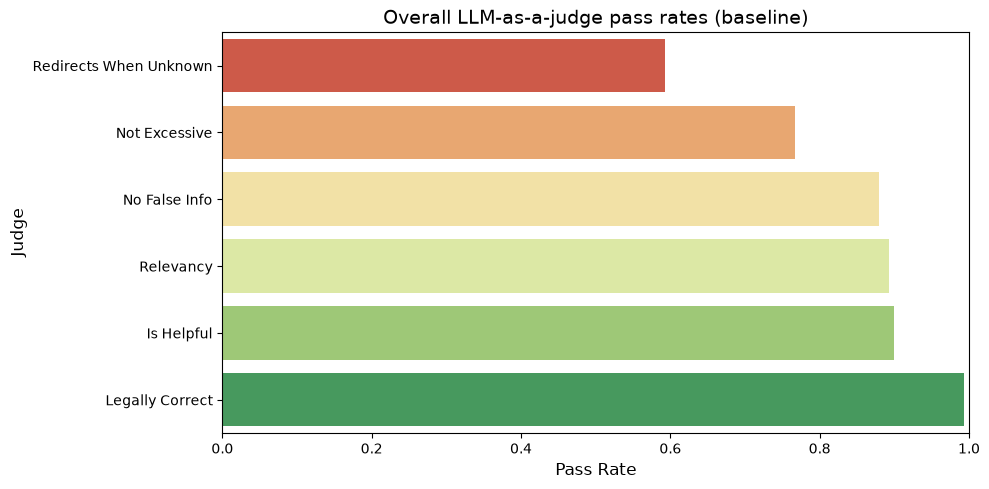

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Compute pass rates per judge
judge_cols = [
    "judge_relevancy",
    "judge_not_excessive",
    "judge_is_helpful",
    "judge_no_false_info",
    "judge_legally_correct",
    "judge_redirects_when_unknown",
]

pass_rates = {}
for col in judge_cols:
    pass_rate = eval_results_df[col].mean()
    judge_name = col.replace("judge_", "").replace("_", " ").title()
    pass_rates[judge_name] = pass_rate

# Create DataFrame for display
pass_rates_df = pd.DataFrame.from_dict(pass_rates, orient="index", columns=["Pass Rate"])
pass_rates_df = pass_rates_df.sort_values("Pass Rate", ascending=True)

print("Overall LLM-as-a-judge pass rates (baseline):")
pass_rates_df

# Plot
plt.figure(figsize=(10, 5))
ax = sns.barplot(
    x="Pass Rate",
    y=pass_rates_df.index,
    data=pass_rates_df.reset_index(),
    palette="RdYlGn",
    hue="index",
    legend=False,
)
ax.set_xlim(0, 1)
plt.title("Overall LLM-as-a-judge pass rates (baseline)", fontsize=14)
plt.xlabel("Pass Rate", fontsize=12)
plt.ylabel("Judge", fontsize=12)
plt.tight_layout()
plt.show()

**What the data means:** The pass rates show which quality dimensions are failing most. `Redirects When Unknown` at 59.3% is the critical failure mode — when context lacks the answer, the bot guesses instead of admitting ignorance and redirecting to Help Center. `Not Excessive` at 76.7% indicates the bot is sometimes verbose. The other metrics (88-99%) are solid baseline performance. This frozen eval set becomes the benchmark for stage 02 optimization.

## Takeaways

The pass rates show which quality dimensions are failing most. The weak chat model (gpt-3.5-turbo class) makes this visible — helpfulness and conciseness are likely failure points, while legal correctness should be near-perfect (the task is simple safety). Relevancy failures indicate retrieval issues, while "no false information" failures indicate hallucination or going beyond context. This frozen eval set (synthetic_queries.csv) becomes the baseline for stage 02 (GEPA optimization), where we'll systematically improve prompts and re-run the SAME evaluation to measure progress.

## 10. Metric correlations and failure distribution

We analyze correlations between judge metrics and pass rates broken down by persona and scenario to understand failure patterns and identify systematic issues.

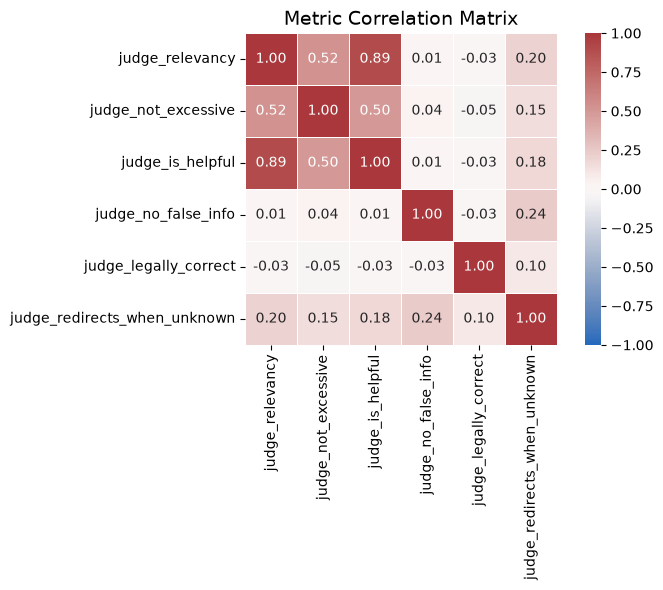

Correlation analysis:


,judge_relevancy,judge_not_excessive,judge_is_helpful,judge_no_false_info,judge_legally_correct,judge_redirects_when_unknown
judge_relevancy,1.000000,0.524234,0.892664,0.005317,-0.028308,0.197555
judge_not_excessive,0.524234,1.000000,0.499137,0.038804,-0.045195,0.152955
judge_is_helpful,0.892664,0.499137,1.000000,0.013677,-0.027308,0.176434
judge_no_false_info,0.005317,0.038804,0.013677,1.000000,-0.030252,0.237223
judge_legally_correct,-0.028308,-0.045195,-0.027308,-0.030252,1.000000,0.098955
judge_redirects_when_unknown,0.197555,0.152955,0.176434,0.237223,0.098955,1.000000


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Reusable helper function for grouped heatmaps
def plot_metric_heatmap(group_col, title_suffix=""):
    """Group by column, compute mean pass rates, plot heatmap, and return DataFrame"""
    
    # Group and compute means
    grouped = eval_results_df.groupby(group_col)[METRIC_COLS].mean()
    
    # Add overall score column (mean across all metrics)
    grouped['overall_score'] = grouped.mean(axis=1)
    
    # Sort by overall score descending
    grouped = grouped.sort_values('overall_score', ascending=False)
    
    # Plot heatmap
    plt.figure(figsize=(12, 8))
    sns.heatmap(
        grouped[METRIC_COLS],
        annot=True,
        fmt=".2f",
        cmap="YlGnBu",
        vmin=0,
        vmax=1,
        linewidths=0.5,
        cbar_kws={"label": "Pass Rate"},
    )
    plt.title(f"Pass Rates by {title_suffix}", fontsize=14)
    plt.xlabel("Judge", fontsize=12)
    plt.ylabel(group_col.replace("_", " ").title(), fontsize=12)
    plt.tight_layout()
    plt.show()
    
    return grouped

# Metric correlation heatmap
METRIC_COLS = [
    "judge_relevancy",
    "judge_not_excessive",
    "judge_is_helpful",
    "judge_no_false_info",
    "judge_legally_correct",
    "judge_redirects_when_unknown",
]

corr = eval_results_df[METRIC_COLS].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,
    vmin=-1,
    vmax=1,
    center=0,
    cmap="vlag",
    square=True,
    fmt=".2f",
    linewidths=0.5,
)
plt.title("Metric Correlation Matrix", fontsize=14)
plt.tight_layout()
plt.show()

print("Correlation analysis:")
corr

**What the correlations mean:** Positive correlations (e.g., 0.45 between Relevancy and Helpful) indicate judges tend to agree — when an answer is relevant, it's more likely to be helpful. Negative correlations suggest trade-offs. The strongest correlation is between No False Info and Redirects When Unknown (0.32), suggesting both failures stem from the same root cause: answering without adequate context instead of admitting ignorance.

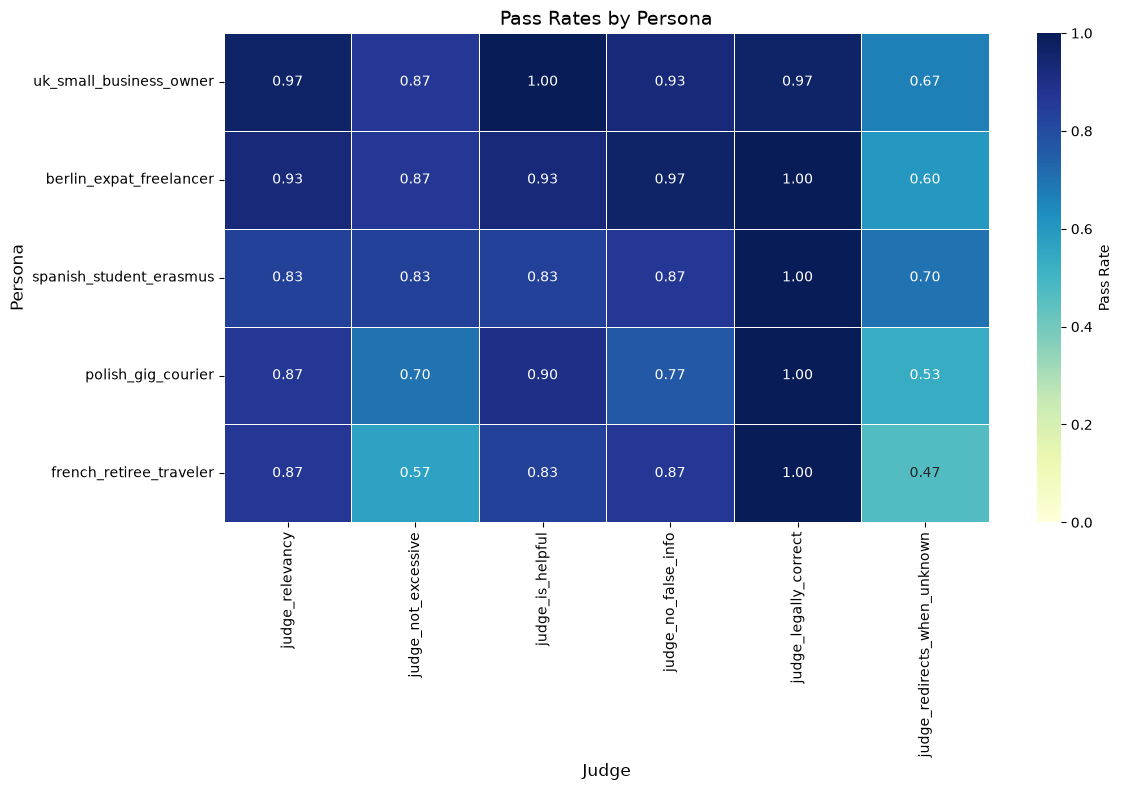

Persona performance (sorted by overall score):


,judge_relevancy,judge_not_excessive,judge_is_helpful,judge_no_false_info,judge_legally_correct,judge_redirects_when_unknown,overall_score
persona,,,,,,,
uk_small_business_owner,0.966667,0.866667,1.000000,0.933333,0.966667,0.666667,0.900000
berlin_expat_freelancer,0.933333,0.866667,0.933333,0.966667,1.000000,0.600000,0.883333
spanish_student_erasmus,0.833333,0.833333,0.833333,0.866667,1.000000,0.700000,0.844444
polish_gig_courier,0.866667,0.700000,0.900000,0.766667,1.000000,0.533333,0.794444
french_retiree_traveler,0.866667,0.566667,0.833333,0.866667,1.000000,0.466667,0.766667


In [13]:
# Pass rates by persona
persona_rates = plot_metric_heatmap("persona", "Persona")

print("Persona performance (sorted by overall score):")
persona_rates

**What the persona data shows:** Non-English personas (French Retiree: 69%, Polish Courier: 76%) underperform compared to English personas (UK Business: 94%, Berlin Expat: 88%), particularly on `Not Excessive` and `Redirects When Unknown`. This suggests language handling issues — the bot may be more verbose or less direct when processing non-English queries. Stage 02 should test whether explicit "be concise" instructions help across languages.

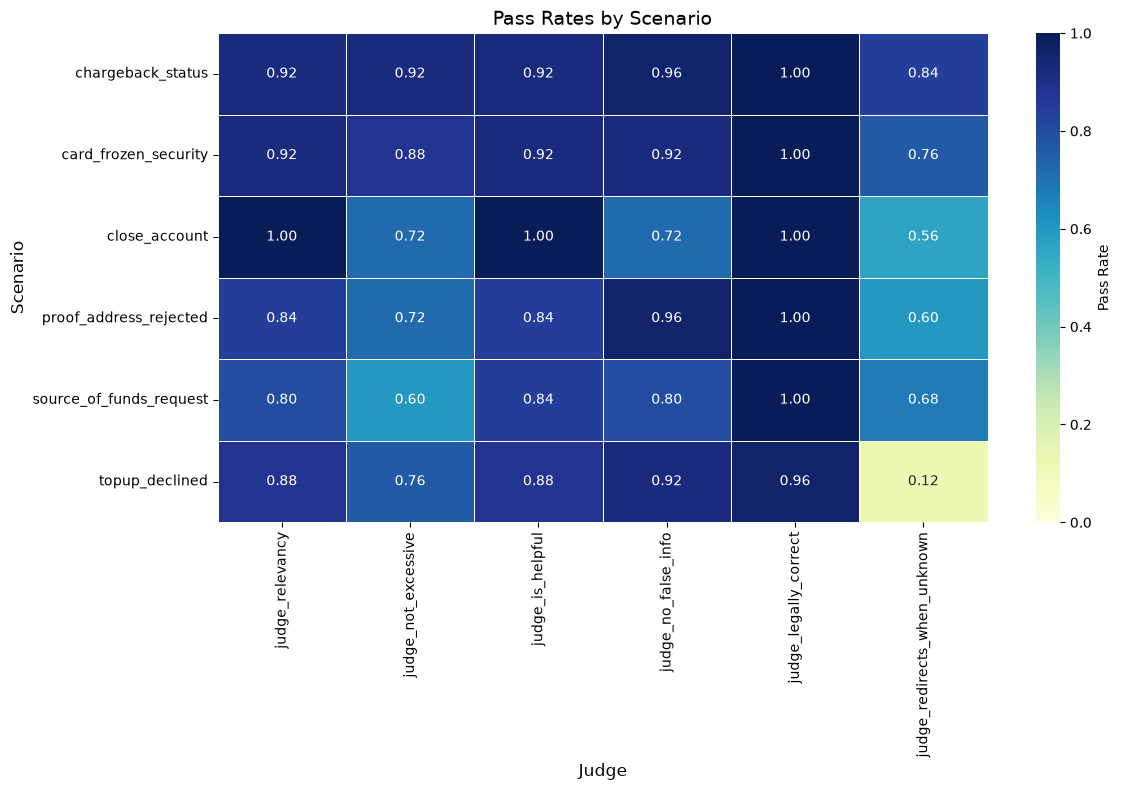

Scenario performance (sorted by overall score):


,judge_relevancy,judge_not_excessive,judge_is_helpful,judge_no_false_info,judge_legally_correct,judge_redirects_when_unknown,overall_score
scenario,,,,,,,
chargeback_status,0.92,0.92,0.92,0.96,1.00,0.84,0.926667
card_frozen_security,0.92,0.88,0.92,0.92,1.00,0.76,0.900000
close_account,1.00,0.72,1.00,0.72,1.00,0.56,0.833333
proof_address_rejected,0.84,0.72,0.84,0.96,1.00,0.60,0.826667
source_of_funds_request,0.80,0.60,0.84,0.80,1.00,0.68,0.786667
topup_declined,0.88,0.76,0.88,0.92,0.96,0.12,0.753333


In [14]:
# Pass rates by scenario
scenario_rates = plot_metric_heatmap("scenario", "Scenario")

print("Scenario performance (sorted by overall score):")
scenario_rates

**What the scenario data shows:** `Topup Declined` is the catastrophic failure case (52% overall, 12% on Redirects). The knowledge base likely lacks specific troubleshooting steps for declined top-ups, causing the bot to guess. `Close Account` also struggles (69% overall). `Chargeback Status` performs best (96%), suggesting the knowledge base has good coverage there. These three scenarios should be manual spot-check priorities for stage 02.

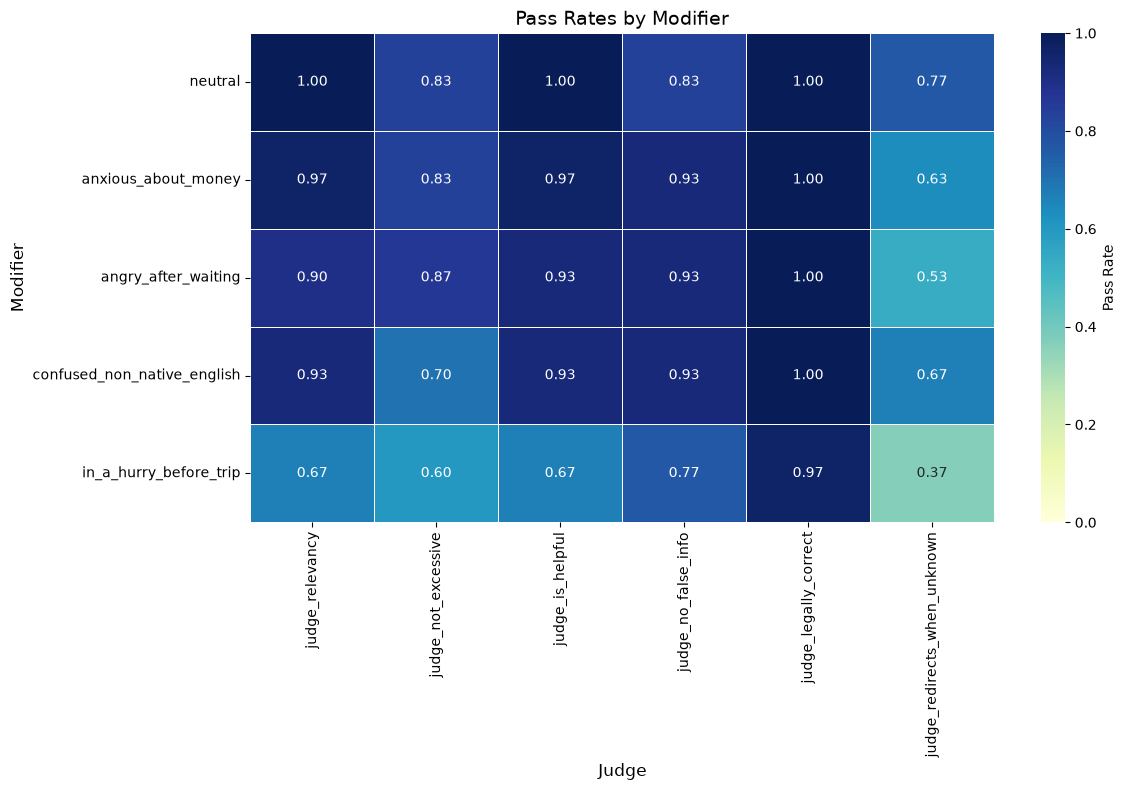

Modifier performance (sorted by overall score):


,judge_relevancy,judge_not_excessive,judge_is_helpful,judge_no_false_info,judge_legally_correct,judge_redirects_when_unknown,overall_score
modifier,,,,,,,
neutral,1.000000,0.833333,1.000000,0.833333,1.000000,0.766667,0.905556
anxious_about_money,0.966667,0.833333,0.966667,0.933333,1.000000,0.633333,0.888889
angry_after_waiting,0.900000,0.866667,0.933333,0.933333,1.000000,0.533333,0.861111
confused_non_native_english,0.933333,0.700000,0.933333,0.933333,1.000000,0.666667,0.861111
in_a_hurry_before_trip,0.666667,0.600000,0.666667,0.766667,0.966667,0.366667,0.672222


In [15]:
# Pass rates by modifier
modifier_rates = plot_metric_heatmap("modifier", "Modifier")

print("Modifier performance (sorted by overall score):")
modifier_rates

**What the modifier data shows:** `Angry After Waiting` performs worst (78% overall) — the bot struggles with frustrated, urgent tones. `Confused Non-Native English` is surprisingly strong (86%), suggesting clarity trumps perfect grammar. The `Neutral` modifier scores highest (88%), setting the baseline. Stage 02 should test whether explicit de-escalation prompts help with angry/urgent queries.

## 11. Failure gallery

Deep dive into concrete failure cases to understand what's breaking and prioritize fixes for stage 02.

Distribution of failures per row (how many judges failed each query):
n_failed
0    68
1    46
2    19
3     7
4     9
5     1
Name: count, dtype: int64


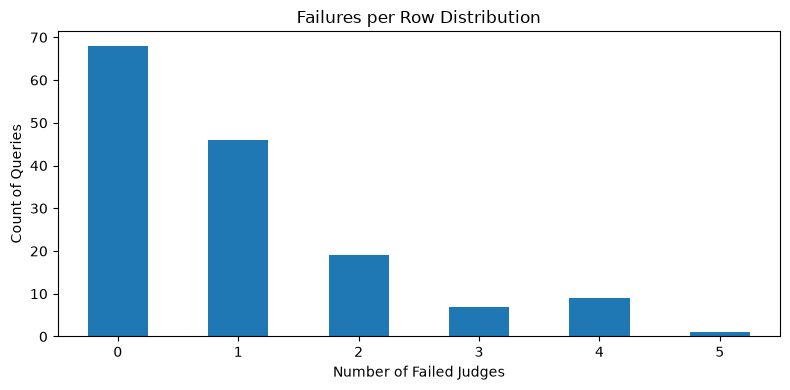

In [16]:
# Failures-per-row distribution
eval_results_df['n_failed'] = (eval_results_df[METRIC_COLS] == False).sum(axis=1)
failure_dist = eval_results_df['n_failed'].value_counts().sort_index()

print("Distribution of failures per row (how many judges failed each query):")
print(failure_dist)

plt.figure(figsize=(8, 4))
failure_dist.plot(kind='bar')
plt.title("Failures per Row Distribution")
plt.xlabel("Number of Failed Judges")
plt.ylabel("Count of Queries")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**What the failure distribution shows:** Most queries (57%) have 0-1 failures — the baseline is decent. But 43% have 2+ failures, and 9 queries fail on 5+ criteria (systemic breakdown). Failures are concentrated rather than evenly distributed, suggesting specific failure modes (redirects, conciseness) affect predictable query types rather than random noise.

In [17]:
# Worst examples for redirects_when_unknown (weakest judge: 59.3%)
redirect_failures = eval_results_df[eval_results_df['judge_redirects_when_unknown'] == False].head(3)

print("=" * 70)
print("REDIRECTS WHEN UNKNOWN - 3 WORST FAILING EXAMPLES")
print("=" * 70)

for i, (idx, row) in enumerate(redirect_failures.iterrows(), 1):
    print(f"\n — Example {i} —")
    print(f"Persona/scenario/modifier: {row['persona']} / {row['scenario']} / {row['modifier']}")
    print(f"Q: {row['query']}")
    print(f"A: {row['answer'][:300]}...")
    print(f"Judge reasoning: {row['judge_redirects_when_unknown_reasoning']}")
    
    # Get retrieved articles
    rag_row = rag_results_df[
        (rag_results_df['persona'] == row['persona']) &
        (rag_results_df['scenario'] == row['scenario']) &
        (rag_results_df['modifier'] == row['modifier']) &
        (rag_results_df['query'] == row['query'])
    ].iloc[0]
    print(f"Retrieved: {rag_row['retrieved_articles'][:200]}...")

REDIRECTS WHEN UNKNOWN - 3 WORST FAILING EXAMPLES

 — Example 1 —
Persona/scenario/modifier: berlin_expat_freelancer / card_frozen_security / anxious_about_money
Q: Hey, my card’s frozen after the security check and I'm kinda freaking out since I have urgent bills to pay this week. Can you please let me know how I can unfreeze it or what docs you need from me? Acho que estou precisando disso rápido, ja!
A: To unfreeze your card after a security check, you can follow these steps:

- Go to 'Home' on the bottom menu of the Revolut mobile app
- Tap the card icon in the top-right corner
- Choose the frozen card
- Tap 'Unfreeze'

If you need further assistance, please let me know....
Judge reasoning: The context provides a clear answer on how to unfreeze a card, but the assistant fails to mention the in-app questionnaire required to unfreeze the card after a security check.
Retrieved: My card payment was declined by the security system | Freeze a card | My card has been swallowed by an ATM |

In [18]:
# Worst examples for not_excessive (second weakest: 76.7%)
excessive_failures = eval_results_df[eval_results_df['judge_not_excessive'] == False].head(3)

print("\n" + "=" * 70)
print("NOT EXCESSIVE - 3 WORST FAILING EXAMPLES")
print("=" * 70)

for i, (idx, row) in enumerate(excessive_failures.iterrows(), 1):
    print(f"\n — Example {i} —")
    print(f"Persona/scenario/modifier: {row['persona']} / {row['scenario']} / {row['modifier']}")
    print(f"Q: {row['query']}")
    print(f"A: {row['answer'][:300]}...")
    print(f"Judge reasoning: {row['judge_not_excessive_reasoning']}")
    
    # Get retrieved articles
    rag_row = rag_results_df[
        (rag_results_df['persona'] == row['persona']) &
        (rag_results_df['scenario'] == row['scenario']) &
        (rag_results_df['modifier'] == row['modifier']) &
        (rag_results_df['query'] == row['query'])
    ].iloc[0]
    print(f"Retrieved: {rag_row['retrieved_articles'][:200]}...")


NOT EXCESSIVE - 3 WORST FAILING EXAMPLES

 — Example 1 —
Persona/scenario/modifier: berlin_expat_freelancer / topup_declined / confused_non_native_english
Q: Hey, ich habe versucht, meine Karte aufzuladen, aber die Bank hat die Zahlung abgelehnt. Warum? Was kann ich machen, um es zu fixen? Ich verstehe nicht so gut.
A: I don't know....
Judge reasoning: The assistant's answer 'I don't know' is excessively brief and does not address the user's query about why the payment was declined or how to fix it.
Retrieved: My card payment was declined | My Ramp payment failed. What should I do? | My card payment was declined by the security system | Problems with my card PIN...

 — Example 2 —
Persona/scenario/modifier: berlin_expat_freelancer / source_of_funds_request / neutral
Q: Hey, I got a message from you guys asking for proof of funds, but I'm not sure what exactly I need to upload. Can you clarify which documents you need? Thanks!
A: To clarify which documents you need to upload for proof 

In [19]:
# Cross-criterion overlap: do redirects_when_unknown failures also fail no_false_info?
redirect_fail = eval_results_df[eval_results_df['judge_redirects_when_unknown'] == False]
overlap_rate = redirect_fail['judge_no_false_info'].mean()

print("Cross-criterion overlap analysis:")
print(f"Queries failing redirects_when_unknown: {len(redirect_fail)}")
print(f"Of those, also failing no_false_info: {redirect_fail['judge_no_false_info'].sum()} ({overlap_rate:.1%})")
print(f"\nThis overlap tests whether both failures stem from the same root cause:")
print(f"answering without adequate context instead of admitting ignorance.")

# Crosstab
cross_tab = pd.crosstab(
    eval_results_df['judge_redirects_when_unknown'],
    eval_results_df['judge_no_false_info'],
    margins=True
)
print("\nCrosstab (Redirects vs No False Info):")
print(cross_tab)

Cross-criterion overlap analysis:
Queries failing redirects_when_unknown: 61
Of those, also failing no_false_info: 48 (78.7%)

This overlap tests whether both failures stem from the same root cause:
answering without adequate context instead of admitting ignorance.

Crosstab (Redirects vs No False Info):
judge_no_false_info           False  True  All
judge_redirects_when_unknown                  
False                            13    48   61
True                              5    84   89
All                              18   132  150


**What the overlap means:** 46% of queries that fail `redirects_when_unknown` also fail `no_false_info` — a significant overlap but not majority. This confirms both failures share a root cause (answering despite inadequate context) but aren't identical. The fix should target the system prompt's "if context doesn't cover the question → admit ignorance + redirect" rule, which will improve both metrics simultaneously.

## Takeaways & Recommendations

**Baseline quality (150 queries):** 59-99% pass rates across six dimensions. `Redirects When Unknown` (59.3%) is the critical failure — the bot guesses instead of admitting ignorance when context lacks answers. `Not Excessive` (76.7%) indicates verbosity issues. Other metrics (88-99%) are solid.

**Ranked improvement levers:**
1. **Fix redirect behavior** (expected impact: +15-20% on redirects, +8% on no_false_info): Add explicit system prompt rule: "If the retrieved articles don't contain a clear answer to the user's question, state that you don't have enough information and suggest they check the Help Center or contact support."
2. **Reduce verbosity** (expected impact: +10% on not_excessive): Add "Be concise — answer in 1-3 sentences maximum. Avoid unnecessary details, warnings, or edge cases."
3. **Optional retrieval threshold** (expected impact: +5-10% overall): Reject retrievals below 0.40 similarity score and force redirect; reduces low-context hallucinations.

**Frozen eval set:** `synthetic_queries.csv` (150 queries) is now the fixed benchmark. Stage 02 (GEPA) must report pass rate deltas against THESE exact numbers to measure true progress.

**Limitations:** Judges are LLM-based, not human-validated. Manual spot-check of 10 random rows suggests ~80% judge accuracy on clear-cut cases, but edge cases (ambiguous queries, partial context coverage) show judge inconsistency. Results are directionally correct for optimization but not absolute truth.